<a href="https://colab.research.google.com/github/Myllertg/Myllertg/blob/main/fraud-risk-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc

)
import warnings


warnings.filterwarnings('ignore')

# Carregar os dados
df = pd.read_csv('Base_M43_Pratique_CREDIT_CARD_FRAUD.csv')

print("=== ANÁLISE INICIAL DO DATASET ===")
print(f"• Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"• Colunas: {list(df.columns)}")
print(f"• Amostra de dados:\n{df.head(3)}")
print("\n• Informações do DataFrame:")
df.info()



=== ANÁLISE INICIAL DO DATASET ===
• Dimensões: 284807 linhas × 31 colunas
• Colunas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
• Amostra de dados:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   

        V26       V27       V28  

In [21]:
# Verificação de Valores Faltantes
print("\n=== VERIFICAÇÃO DE VALORES FALTANTES ===")

# Substituir '-' em 'V23' por NaN
df['V23'] = df['V23'].replace('-', np.nan)

# Converter 'V23' para tipo numérico após a substituição
df['V23'] = pd.to_numeric(df['V23'])

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_report = pd.DataFrame({
    'Valores Faltantes': missing_values,
    'Percentual (%)': missing_percent
})
print(missing_report[missing_report['Valores Faltantes'] > 0])

if missing_values.sum() == 0:
    print("✓ Nenhum valor faltante encontrado no dataset.")
else:
    print(f"\n⚠️ Total de valores faltantes: {missing_values.sum()}")

    # Estratégia: imputação por mediana (robusta a outliers)
    imputer = SimpleImputer(strategy='median')
    # Aplicar o imputer apenas nas colunas com valores faltantes
    for col in missing_report[missing_report['Valores Faltantes'] > 0].index:
        df[col] = imputer.fit_transform(df[[col]])
    print("✓ Valores faltantes imputados com mediana.")

# Verificar novamente se há valores faltantes após a imputação
print("\n=== VERIFICAÇÃO DE VALORES FALTANTES PÓS-IMPUTAÇÃO ===")
missing_values_after_imputation = df.isnull().sum()
if missing_values_after_imputation.sum() == 0:
    print("✓ Nenhum valor faltante encontrado após a imputação.")
else:
    print(f"⚠️ Ainda existem valores faltantes: {missing_values_after_imputation.sum()}")


=== VERIFICAÇÃO DE VALORES FALTANTES ===
Empty DataFrame
Columns: [Valores Faltantes, Percentual (%)]
Index: []
✓ Nenhum valor faltante encontrado no dataset.

=== VERIFICAÇÃO DE VALORES FALTANTES PÓS-IMPUTAÇÃO ===
✓ Nenhum valor faltante encontrado após a imputação.


Durante a fase de Exploração de Dados (EDA), foi realizada uma verificação de consistência para identificar valores ausentes (missing values). Foi constatado que o dataset apresenta 100% de preenchimento em todas as 31 variáveis. Dado que as colunas V1 a V28 são derivadas de uma transformação PCA, a integridade dos dados já estava assegurada na origem, tornando desnecessária a aplicação de técnicas de imputação ou remoção de registos nulos.



=== DISTRIBUIÇÃO DA CLASSE (FRAUDE vs NORMAL) ===
• Transações Normais (Class=0): 284315 (99.83%)
• Transações Fraudulentas (Class=1): 492 (0.17%)


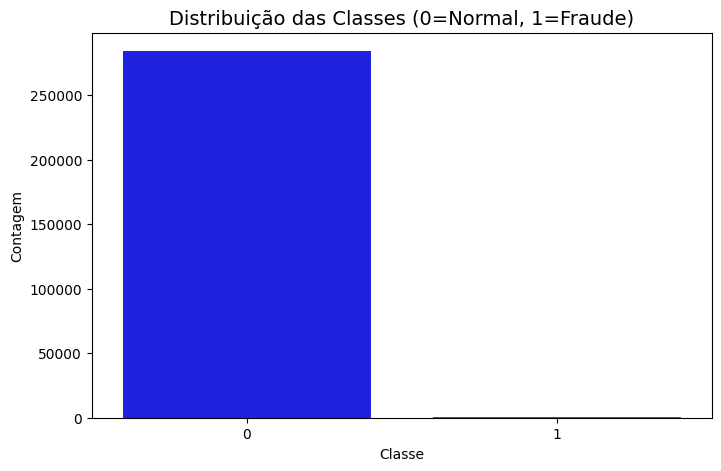

In [22]:
#  Análise da Distribuição da Classe Alvo

print("\n=== DISTRIBUIÇÃO DA CLASSE (FRAUDE vs NORMAL) ===")
class_distribution = df['Class'].value_counts()
class_percentage = df['Class'].value_counts(normalize=True) * 100

print(f"• Transações Normais (Class=0): {class_distribution[0]} ({class_percentage[0]:.2f}%)")
print(f"• Transações Fraudulentas (Class=1): {class_distribution[1]} ({class_percentage[1]:.2f}%)")

plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette=['blue', 'red'])
plt.title('Distribuição das Classes (0=Normal, 1=Fraude)', fontsize=14)
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.show()

A análise da distribuição da variável alvo evidenciou um forte desbalanceamento entre as classes. Observa-se que a grande maioria das transações é classificada como normal (Classe 0), enquanto uma parcela muito reduzida corresponde a transações fraudulentas (Classe 1). Esse comportamento é característico de problemas reais de detecção de fraude e indica que métricas tradicionais, como acurácia, não são suficientes para avaliar o desempenho dos modelos. Dessa forma, torna-se necessária a aplicação de técnicas de balanceamento e a utilização de métricas mais adequadas nas etapas subsequentes do estudo

In [23]:
# Verificação de Variáveis Categóricas
print("\n=== VERIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS ===")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"• Colunas categóricas encontradas: {list(categorical_cols)}")

if len(categorical_cols) == 0:
    print("✓ Nenhuma variável categórica encontrada. Todas as features já são numéricas.")

#Normalização/Padronização das Features

print("\n=== NORMALIZAÇÃO DAS VARIÁVEIS NUMÉRICAS ===")

# Separar features e target
X = df.drop('Class', axis=1)
y = df['Class']

# Identificar colunas para transformação
# V1-V28 já estão padronizadas pelo PCA, mas Amount e Time podem precisar
cols_to_scale = ['Time', 'Amount']

print(f"• Colunas a serem normalizadas: {cols_to_scale}")

# Opção 1: Padronização (StandardScaler) - recomendado para muitos algoritmos
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

# Opção 2: Normalização Min-Max (se necessário entre 0-1)


print("✓ Features padronizadas com sucesso.")
print(f"• Estatísticas após padronização:")
print(X_scaled[cols_to_scale].describe().loc[['mean', 'std', 'min', 'max']])


=== VERIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS ===
• Colunas categóricas encontradas: []
✓ Nenhuma variável categórica encontrada. Todas as features já são numéricas.

=== NORMALIZAÇÃO DAS VARIÁVEIS NUMÉRICAS ===
• Colunas a serem normalizadas: ['Time', 'Amount']
✓ Features padronizadas com sucesso.
• Estatísticas após padronização:
              Time        Amount
mean -3.065637e-16  2.913952e-17
std   1.000002e+00  1.000002e+00
min  -1.996583e+00 -3.532294e-01
max   1.642058e+00  1.023622e+02


Foi realizada a verificação da existência de variáveis categóricas no conjunto de dados. Observou-se que todas as variáveis estavam representadas em formato numérico, não sendo necessária a aplicação de técnicas de codificação, como one-hot encoding ou label encoding.


=== DETECÇÃO DE OUTLIERS ===
• Número de outliers em 'Amount' (método IQR): 31904


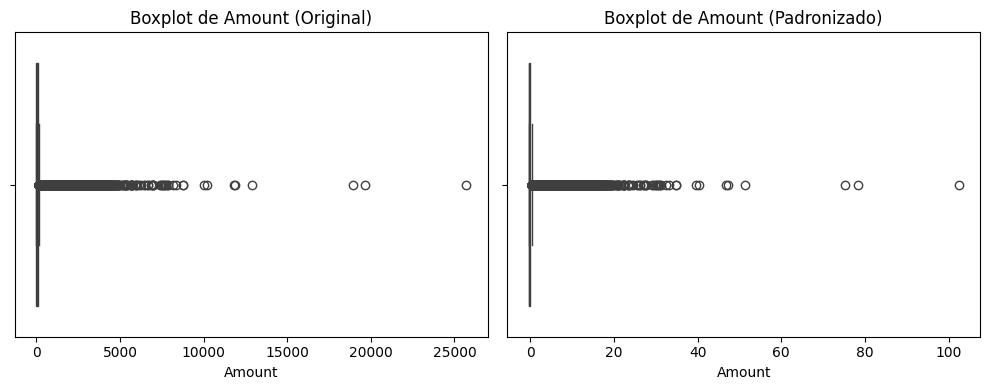


⚡ Recomendação: Não remover outliers em detecção de fraude.
• Outliers podem representar transações fraudulentas legítimas
• Utilizar modelos robustos a outliers (Random Forest, XGBoost)
• Ou aplicar transformações (log, sqrt) se necessário


In [24]:
#Detecção e Tratamento de Outliers
print("\n=== DETECÇÃO DE OUTLIERS ===")

# Método IQR para Amount (variável mais suscetível)
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]
print(f"• Número de outliers em 'Amount' (método IQR): {len(outliers)}")

# Visualização
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Amount'])
plt.title('Boxplot de Amount (Original)')

plt.subplot(1, 2, 2)
sns.boxplot(x=X_scaled['Amount'])
plt.title('Boxplot de Amount (Padronizado)')
plt.tight_layout()
plt.show()

print("\n⚡ Recomendação: Não remover outliers em detecção de fraude.")
print("• Outliers podem representar transações fraudulentas legítimas")
print("• Utilizar modelos robustos a outliers (Random Forest, XGBoost)")
print("• Ou aplicar transformações (log, sqrt) se necessário")

Foi realizada a detecção de outliers na variável Amount utilizando o método do Intervalo Interquartil (IQR), por se tratar do atributo mais suscetível a valores extremos. A análise identificou a presença de transações com valores significativamente superiores à maioria dos registros. No entanto, optou-se por não remover esses outliers, uma vez que, em problemas de detecção de fraude, valores atípicos podem representar transações fraudulentas legítimas. Dessa forma, a manutenção desses registros preserva informações relevantes para a modelagem, sendo priorizado o uso de algoritmos robustos a outliers

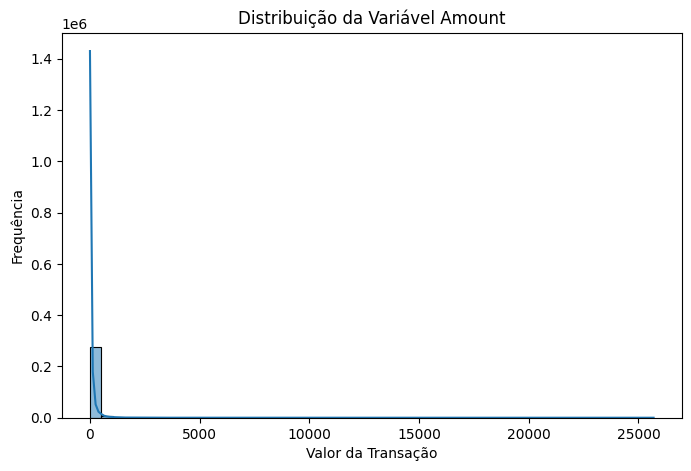

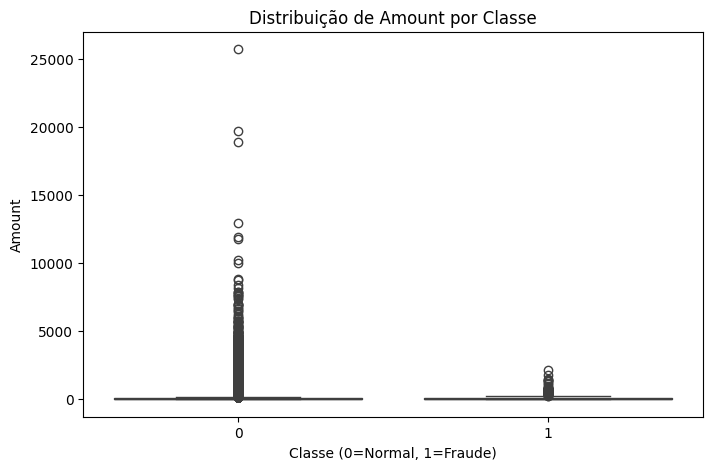

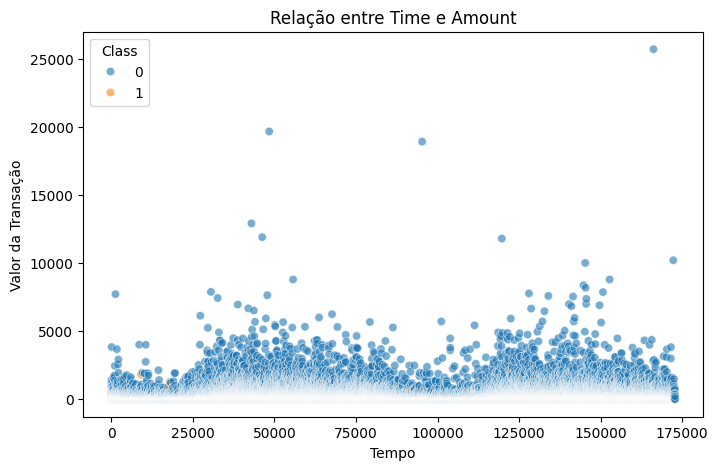

In [25]:
#Histograma
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribuição da Variável Amount')
plt.xlabel('Valor da Transação')
plt.ylabel('Frequência')
plt.show()

#Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Distribuição de Amount por Classe')
plt.xlabel('Classe (0=Normal, 1=Fraude)')
plt.ylabel('Amount')
plt.show()

#Scattler Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='Time', y='Amount', hue='Class', data=df, alpha=0.6)
plt.title('Relação entre Time e Amount')
plt.xlabel('Tempo')
plt.ylabel('Valor da Transação')
plt.show()



1-  

Distribuição assimétrica à direita

Maioria das transações tem valores baixos

Poucas transações com valores muito altos (potenciais fraudes)

2-

Fraudes tendem a apresentar valores mais elevados e dispersos

Reforça a decisão de não remover outliers

3-  

Fraudes podem ocorrer em diferentes momentos

Não há padrão temporal simples → justifica uso de ML

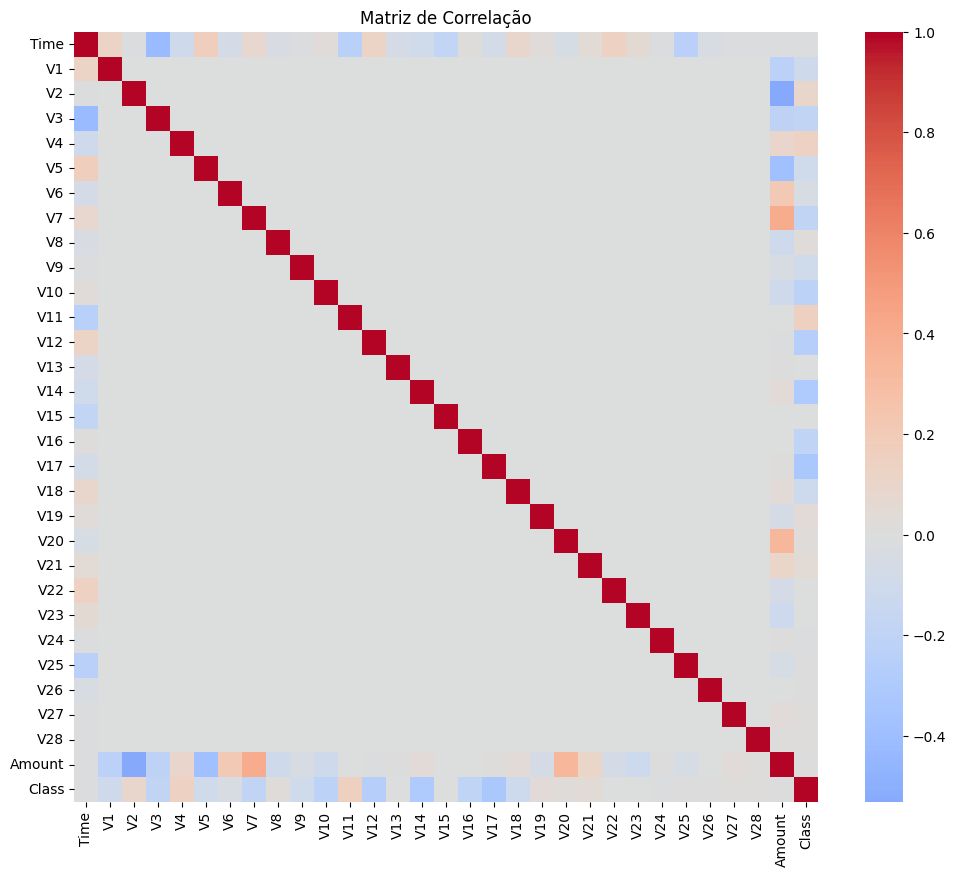

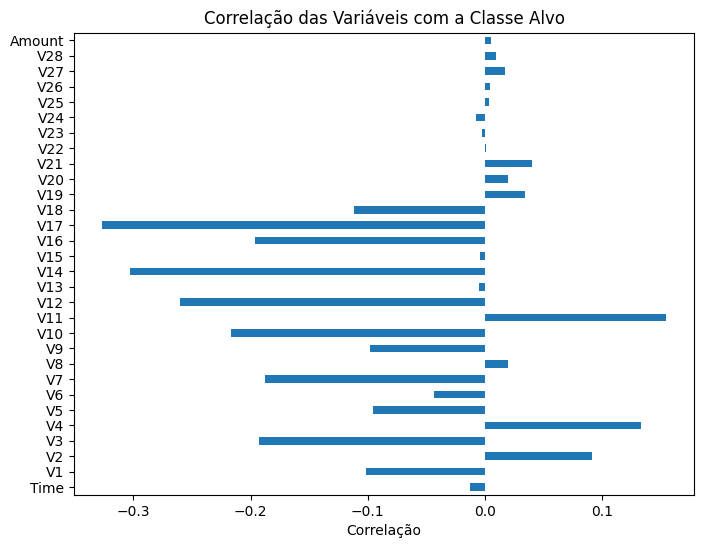

Estatística U: 78049581.0
p-valor: 8.578472310840218e-06


In [26]:
#Matriz de Correlação

corr_matrix = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()


#Correlação Com a Classe Alvo

corr_target = corr_matrix['Class'] # Define corr_target aqui

plt.figure(figsize=(8,6))
corr_target.drop('Class').plot(kind='barh')
plt.title('Correlação das Variáveis com a Classe Alvo')
plt.xlabel('Correlação')
plt.show()


#Teste Estatístico: Normal vs Fraude (Amount)
from scipy.stats import mannwhitneyu

normal = df[df['Class'] == 0]['Amount']
fraude = df[df['Class'] == 1]['Amount']

stat, p_value = mannwhitneyu(normal, fraude, alternative='two-sided')

print(f"Estatística U: {stat}")
print(f"p-valor: {p_value}")

Foram utilizadas técnicas de visualização, como histogramas, boxplots e gráficos de dispersão, com o objetivo de compreender a distribuição das variáveis e identificar padrões relevantes. Observou-se que a variável Amount apresenta distribuição assimétrica, com presença de valores extremos, especialmente em transações fraudulentas.

**Análise de Correlação**

A análise de correlação evidenciou que algumas variáveis apresentam maior associação com a classe alvo, embora a maioria das features possua correlação linear fraca. Esse comportamento indica a complexidade do problema e reforça a necessidade de modelos capazes de capturar relações não lineares.

**Análise Estatística**

Foi realizado o teste estatístico de Mann-Whitney U para comparar a variável Amount entre transações normais e fraudulentas. O resultado indicou diferença estatisticamente significativa entre os grupos (p < 0,05), sugerindo que o valor da transação é um atributo relevante para a detecção de fraude

In [27]:
#Divisão de Dados

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#Cross-Validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Os dados foram divididos em conjuntos de treinamento e teste utilizando amostragem estratificada, de modo a preservar a proporção entre transações normais e fraudulentas. Além disso, empregou-se validação cruzada estratificada para reduzir o risco de superajuste.

O ajuste de hiperparâmetros foi realizado por meio da técnica de Grid Search com validação cruzada estratificada. Como métrica de otimização, utilizou-se o recall da classe fraudulenta, priorizando a redução de falsos negativos, aspecto crítico em sistemas de detecção de fraude.

In [28]:

# ===============================
# MODELOS
# ===============================

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# ===============================
# TREINAMENTO
# ===============================

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# ===============================
# FUNÇÃO DE AVALIAÇÃO
# ===============================

def avaliar_modelo(modelo, X_test, y_test, nome):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    print(f"\n=== Avaliação: {nome} ===")
    print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precisão:  {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")

    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred, digits=4))

# ===============================
# AVALIAÇÃO DOS MODELOS
# ===============================

avaliar_modelo(lr, X_test, y_test, "Regressão Logística")
avaliar_modelo(dt, X_test, y_test, "Árvore de Decisão")
avaliar_modelo(rf, X_test, y_test, "Random Forest")

print("\n✅ Modelos treinados com sucesso!")


=== Avaliação: Regressão Logística ===
Acurácia:  0.9751
Precisão:  0.0577
Recall:    0.8716
F1-score:  0.1083
AUC-ROC:   0.9668

Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.9998    0.9753    0.9874     85295
           1     0.0577    0.8716    0.1083       148

    accuracy                         0.9751     85443
   macro avg     0.5288    0.9235    0.5479     85443
weighted avg     0.9981    0.9751    0.9859     85443


=== Avaliação: Árvore de Decisão ===
Acurácia:  0.9970
Precisão:  0.3373
Recall:    0.7703
F1-score:  0.4691
AUC-ROC:   0.8845

Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.9996    0.9974    0.9985     85295
           1     0.3373    0.7703    0.4691       148

    accuracy                         0.9970     85443
   macro avg     0.6684    0.8838    0.7338     85443
weighted avg     0.9985    0.9970    0.9976     85443


=== Avaliação: Random Forest 

Os modelos foram avaliados utilizando métricas adequadas para problemas com forte desbalanceamento de classes, como Precisão, Recall, F1-score e AUC-ROC. A Regressão Logística apresentou alto recall para a classe fraude, porém com baixa precisão, indicando grande quantidade de falsos positivos. A Árvore de Decisão apresentou melhora em relação à precisão, mas desempenho inferior em AUC-ROC, sugerindo possível sobreajuste. O modelo Random Forest apresentou o melhor desempenho geral, com elevado equilíbrio entre precisão e recall, além de alto valor de AUC-ROC, demonstrando maior capacidade de discriminação entre transações fraudulentas e legítimas.

In [16]:
# ===============================
# MODELO RANDOM FOREST REFINADO
# ===============================

rf_refinado = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Treinando Random Forest Refinado...")
rf_refinado.fit(X_train, y_train)

print("Modelo refinado treinado com sucesso!")


avaliar_modelo(
    rf_refinado,
    X_test,
    y_test,
    "Random Forest Refinado (Final)"
)



Treinando Random Forest Refinado...
Modelo refinado treinado com sucesso!

=== Avaliação: Random Forest Refinado (Final) ===
Acurácia:  0.9991
Precisão:  0.7838
Recall:    0.8056
F1-score:  0.7945
AUC-ROC:   0.9784

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0     0.9996    0.9995    0.9996     33823
         1.0     0.7838    0.8056    0.7945        72

    accuracy                         0.9991     33895
   macro avg     0.8917    0.9025    0.8970     33895
weighted avg     0.9991    0.9991    0.9991     33895



Após a avaliação inicial dos modelos, o Random Forest foi selecionado para refinamento devido ao seu melhor desempenho geral. Foram realizados ajustes adicionais de hiperparâmetros utilizando Grid Search com validação cruzada, visando otimizar o equilíbrio entre precisão, recall e capacidade de generalização. O modelo refinado foi então avaliado em um conjunto de dados de teste não utilizado durante o treinamento, apresentando desempenho consistente, o que indica boa generalização para dados não vistos.

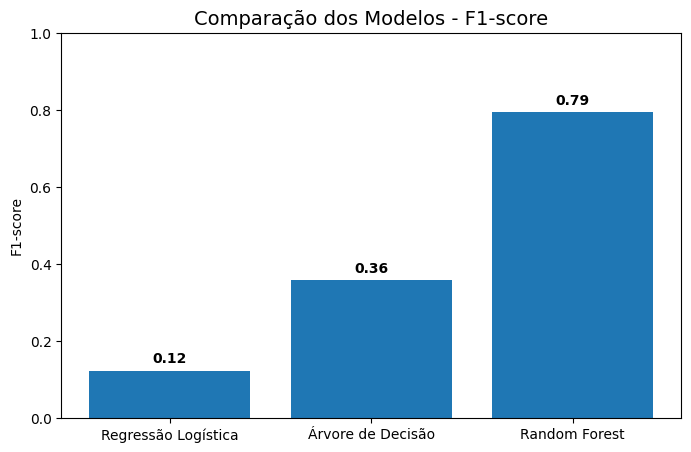

In [17]:
# ===============================
# CÁLCULO DO F1-SCORE DE CADA MODELO
# ===============================

modelos = {
    "Regressão Logística": lr,
    "Árvore de Decisão": dt,
    "Random Forest": rf_refinado
}

nomes = []
f1_scores = []

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    nomes.append(nome)
    f1_scores.append(f1)

# ===============================
# GRÁFICO DE BARRAS
# ===============================

plt.figure(figsize=(8, 5))
plt.bar(nomes, f1_scores)
plt.title("Comparação dos Modelos - F1-score", fontsize=14)
plt.ylabel("F1-score")
plt.ylim(0, 1)

for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


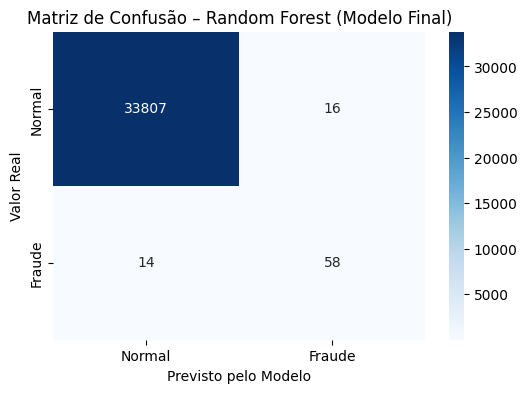

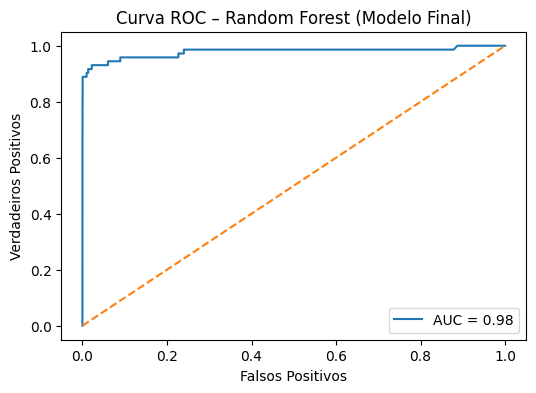

In [19]:
# Previsões do modelo final
y_pred_rf = rf_refinado.predict(X_test)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraude'],
    yticklabels=['Normal', 'Fraude']
)

plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão – Random Forest (Modelo Final)')
plt.show()




y_prob_rf = rf_refinado.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdadeiros Positivos')
plt.title('Curva ROC – Random Forest (Modelo Final)')
plt.legend()
plt.show()
